##FOLLOW THESE STEPS TO RUN THIS WORKBOOK


1. Run all cells by choosing the commands in this workbook as illustrated to the right:
 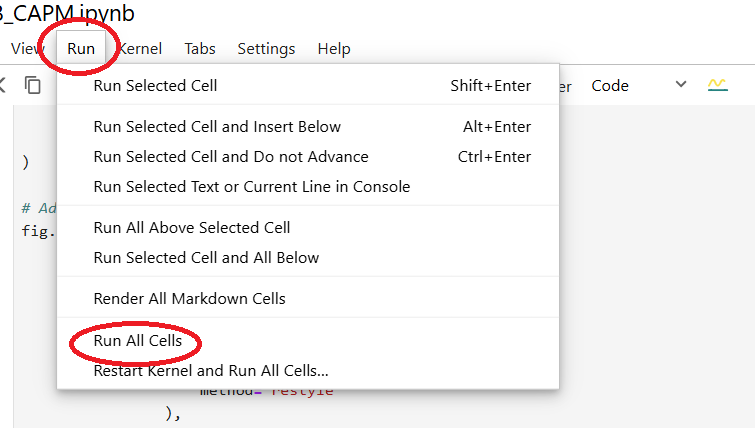

2.  Next, collapse all code as you will see to the commands circled here on the right:
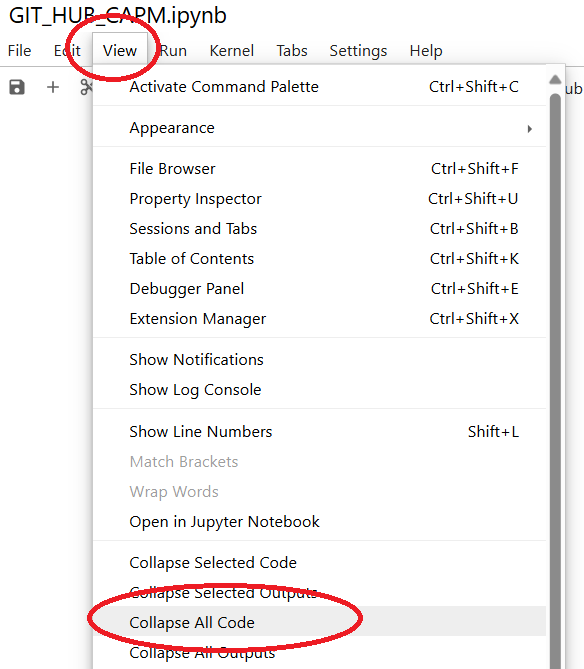

3.  Additionally, towards the end of the workbook, you'll find interactive graphs and charts that respond as you hover your mouse over them.

In [9]:
!pip install pycaret
!pip install yfinance
import datetime
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
!pip install plotly
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ff
!pip install dash
from dash import Dash, dcc, html, Input, Output
from sklearn.model_selection import train_test_split
from sklearn import linear_model, tree, neighbors
import plotly.graph_objects as go
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from plotly.subplots import make_subplots
from sklearn.preprocessing import PolynomialFeatures


[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


##CODE WITHIN THIS WORKBOOK WAS CREATED THROUGH PERONAL UNDERSTANDING AND ALSO THE ASSISTANCE OF MICROSOFT COPILOT AND CHAT GPT 3.5 SNIPPETS WERE CREATED AND ITERATED OVER AND OVER TO PRODUCE A CUSTOMIZED OUTPUT

##THE DOWNLOADED RETURNS WERE NORMALIZED

**Normalized Returns: Comparing Exxon and the S&P 500**

Normalizing is similar to taking two objects that are vastly different in weight and converting them to objects that are similar and can be weighed on the same scale.  There are mathematical techniques which make this conversion possible.

The below code will normailize the returns and put them into a chart.






[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


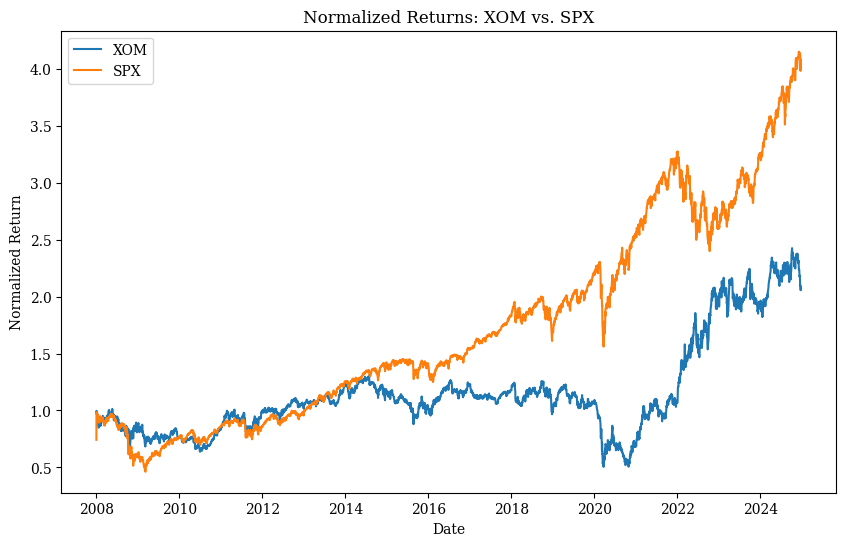

In [10]:
# Define start and end dates
!pip install seaborn
plt.rcParams['font.family'] = 'serif'
start = datetime.datetime(2008, 1, 1)
end = datetime.datetime(2024, 12, 26)

# Fetch data for S&P 500 (SPX) from Yahoo Finance using yfinance
df_spx = yf.download('^GSPC', start=start, end=end)  # Use '^GSPC' instead of 'SPX'
df_xom = yf.download('XOM', start=start, end=end)  # Use XOM
# Calculate daily returns
df_xom['Daily_Return'] = df_xom['Open'].pct_change()
df_spx['Daily_Return'] = df_spx['Open'].pct_change()

# Normalize returns
df_xom['Normalized_Return'] = (1 + df_xom['Daily_Return']).cumprod()
df_spx['Normalized_Return'] = (1 + df_spx['Daily_Return']).cumprod()

#Remove Null Values Replace with Mode
for column in df_spx.columns:
    df_spx[column].fillna(df_spx[column].mode()[0], inplace=True)
for column in df_xom.columns:
    df_xom[column].fillna(df_xom[column].mode()[0], inplace=True)

# Plot normalized returns
plt.figure(figsize=(10, 6))
plt.plot(df_xom.index, df_xom['Normalized_Return'], label='XOM')
plt.plot(df_spx.index, df_spx['Normalized_Return'], label='SPX')
plt.xlabel('Date')
plt.ylabel('Normalized Return')
plt.title('Normalized Returns: XOM vs. SPX')
plt.legend()
plt.show()

##For those familiar with statistics, executing the following code will generate a chart for a high-level overview of the S&P.

In [11]:
df_spx.describe()

Price,Close,High,Low,Open,Volume,Daily_Return,Normalized_Return
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC,,
count,4275.000000,4275.000000,4275.000000,4275.000000,4.275000e+03,4275.000000,4275.000000
mean,2531.062159,2544.762705,2515.445085,2530.626910,4.101443e+09,0.000375,1.723835
std,1299.411522,1305.037398,1293.148211,1299.201100,1.107450e+09,0.011597,0.885090
min,676.530029,695.270020,666.789978,679.280029,1.025000e+09,-0.087119,0.462734
25%,1372.075012,1381.960022,1364.825012,1372.154968,3.422585e+09,-0.003942,0.934634
50%,2122.850098,2128.030029,2112.709961,2121.300049,3.861360e+09,0.000861,1.445057
75%,3393.919922,3422.125000,3374.489990,3397.829956,4.521050e+09,0.005645,2.314645
max,6090.270020,6099.970215,6079.979980,6089.029785,1.145623e+10,0.106712,4.147925


##The next cell can be run to get the same statistics for Exxon.

In [12]:
df_xom.describe()

Price,Close,High,Low,Open,Volume,Daily_Return,Normalized_Return
Ticker,XOM,XOM,XOM,XOM,XOM,,
count,4275.000000,4275.000000,4275.000000,4275.000000,4.275000e+03,4275.000000,4275.000000
mean,58.973755,59.509185,58.411065,58.961376,1.916675e+07,0.000274,1.160811
std,20.880236,21.062201,20.696551,20.877960,1.088054e+07,0.017157,0.411043
min,24.809378,25.795442,23.752317,25.661336,3.851300e+06,-0.177062,0.505214
25%,47.191454,47.708014,46.726523,47.162011,1.172200e+07,-0.007838,0.928514
50%,54.725079,55.215303,54.344734,54.761743,1.625710e+07,0.000398,1.078136
75%,60.401997,60.772622,59.907014,60.364333,2.325820e+07,0.008486,1.188438
max,123.245819,124.199378,122.744458,123.127850,1.180235e+08,0.156394,2.424111


[*********************100%***********************]  1 of 1 completed


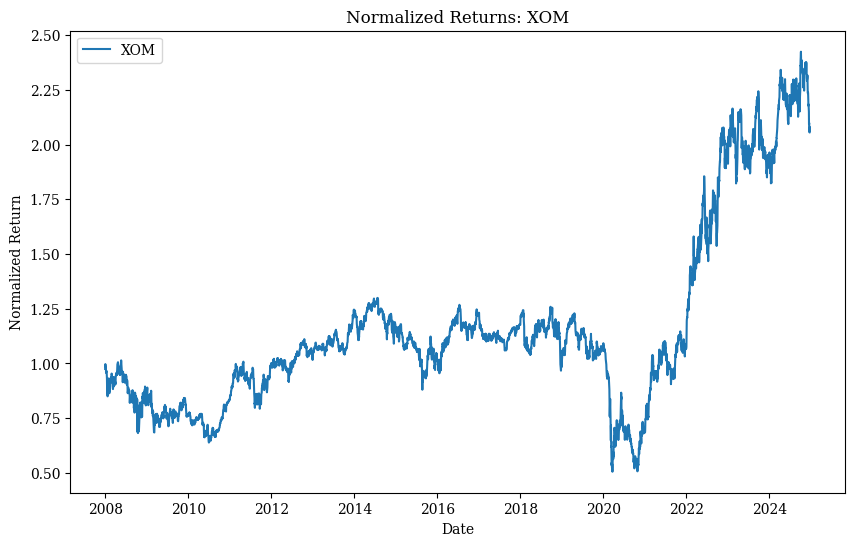

In [13]:
# Define start and end dates
plt.rcParams['font.family'] = 'serif'
start = datetime.datetime(2008, 1, 1)
end = datetime.datetime(2024, 12, 26)
from sklearn.impute import SimpleImputer

# Fetch data for XOM from Yahoo Finance using yfinance
#df_spx_gradient = yf.download('^GSPC', start=start, end=end)  # Use '^GSPC' instead of 'SPX'
df_xom_gradient = yf.download('XOM', start=start, end=end)  # Use XOM
# Calculate daily returns
df_xom_gradient['Daily_Return'] = df_xom['Open'].pct_change()
#df_spx_gradient['Daily_Return'] = df_spx['Open'].pct_change()

# Normalize returns
df_xom_gradient['Normalized_Return'] = (1 + df_xom_gradient['Daily_Return']).cumprod()
#df_spx_gradient['Normalized_Return'] = (1 + df_spx['Daily_Return']).cumprod()

#Remove Null Values Replace with Mode
#for column in df_xom_gradient.columns:
    #df_spx_gradient[column].fillna(df_spx[column].mode()[0], inplace=True)
for column in df_xom_gradient.columns:
    df_xom[column].fillna(df_xom[column].mode()[0], inplace=True)

# Plot normalized returns
plt.figure(figsize=(10, 6))
plt.plot(df_xom_gradient.index, df_xom['Normalized_Return'], label='XOM')
#plt.plot(df_spx_gradient.index, df_spx_gradient['Normalized_Return'], label='SPX')
plt.xlabel('Date')
plt.ylabel('Normalized Return')
plt.title('Normalized Returns: XOM')
plt.legend()
plt.show()

## CAPM Analysis: Comparing Exxon and S&P 500

Next you will discover the Beta of Exxon which is the risk of Exxon stock in relation to the overall market.

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


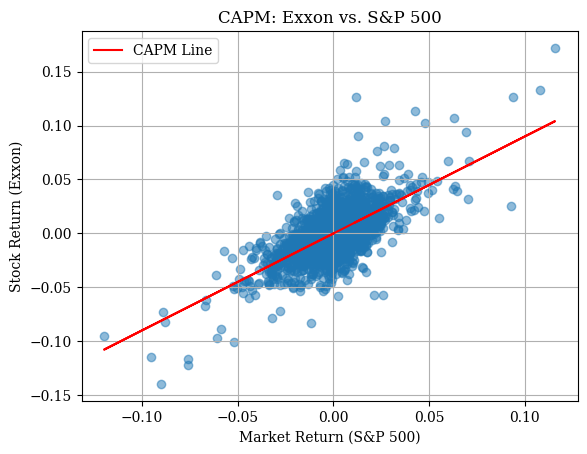

Beta (market risk) for Exxon: 0.8986662648800285


In [14]:

# Define start and end dates
start = datetime.datetime(2008, 1, 1)
end = datetime.datetime(2024, 12, 26)

# Fetch data for Exxon (XOM) and S&P 500 (SPY) from Yahoo Finance using yfinance
df_xom = yf.download('XOM', start=start, end=end)
df_spx = yf.download('^GSPC', start=start, end=end)

# Calculate daily returns for Exxon and the S&P 500
df_xom['Daily_Return'] = df_xom['Close'].pct_change(1)
df_spx['Daily_Return'] = df_spx['Close'].pct_change(1)

# Drop NaN values
df_xom.dropna(inplace=True)
df_spx.dropna(inplace=True)

# Perform linear regression to estimate beta coefficient (market risk) for Exxon
slope, intercept, r_value, p_value, std_err = stats.linregress(df_spx['Daily_Return'], df_xom['Daily_Return'])

# Plot CAPM regression line
plt.scatter(df_spx['Daily_Return'], df_xom['Daily_Return'], alpha=0.5)
plt.plot(df_spx['Daily_Return'], intercept + slope * df_spx['Daily_Return'], color='red', label='CAPM Line')
plt.xlabel('Market Return (S&P 500)')
plt.ylabel('Stock Return (Exxon)')
plt.title('CAPM: Exxon vs. S&P 500')
plt.legend()
plt.grid(True)
plt.show()

# Output beta coefficient
print("Beta (market risk) for Exxon:", slope)

**K-means clustering** K-means clustering is a very useful machine learning tool. The most simplistic explanation is that it allows the creation of a model that will break apart data based on a chosen number of datapoints (centroids) and begin to calculate the mean of each datapoint. The data is stripped of all descriptions and the model itself operates based on unsupervised learning. After a multitude of calculations the datapoints will begin to group into clusters based upon their mean which can than be evaluated to assimilate them into like values. A similar concept is Principal Component Analysis (PCA). Think of PCA like taking a tall stack of pieces to a complex puzzle and putting them together as a flat surface that creates a meaningful image which can than be interpreted. All pieces are not used in order to capture the image. Just those that provide the clearest definition. The mathematical computations are involved and can be studied by the reader who may be interested in understanding the detailed nuances of the calculations. In the below K-means example one cluster may represent market volume while another may represent the the change in normalized returns etc.

Source of Undersatnding and Writing based on concepts of (Dr. Caroline Uhler, MIT Class Lectures, 2023).

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


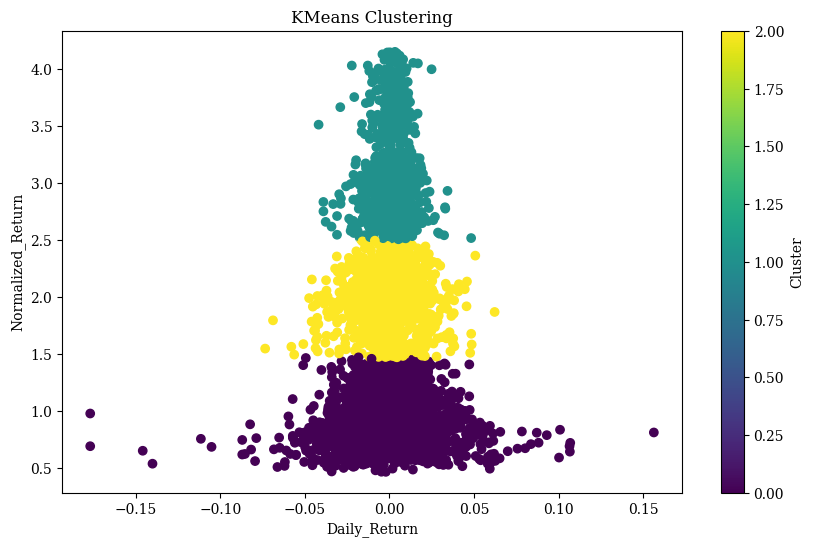

Cluster 0:
Price             Close         High          Low         Open        Volume  \
Ticker            ^GSPC        ^GSPC        ^GSPC        ^GSPC         ^GSPC   
Date                                                                           
2008-01-02  1447.160034  1471.770020  1442.069946  1467.969971  3.452650e+09   
2008-01-03  1447.160034  1456.800049  1443.729980  1447.550049  3.429500e+09   
2008-01-04  1411.630005  1444.010010  1411.189941  1444.010010  4.166000e+09   
2008-01-07  1416.180054  1423.869995  1403.449951  1414.069946  4.221260e+09   
2008-01-08  1390.189941  1430.280029  1388.300049  1415.709961  4.705390e+09   
...                 ...          ...          ...          ...           ...   
2022-03-22          NaN          NaN          NaN          NaN           NaN   
2022-03-29          NaN          NaN          NaN          NaN           NaN   
2022-04-01          NaN          NaN          NaN          NaN           NaN   
2022-04-25          NaN      

In [15]:

# Define start and end dates
start = datetime.datetime(2008, 1, 1)
end = datetime.datetime(2024, 12, 26)

# Fetch data for S&P 500 (SPX) from Yahoo Finance using yfinance
df_spx = yf.download('^GSPC', start=start, end=end)  # Use '^GSPC' instead of 'SPX'
df_xom = yf.download('XOM', start=start, end=end)  # Use XOM
# Calculate daily returns
df_xom['Daily_Return'] = df_xom['Open'].pct_change()
df_spx['Daily_Return'] = df_spx['Open'].pct_change()

# Normalize returns
df_xom['Normalized_Return'] = (1 + df_xom['Daily_Return']).cumprod()
df_spx['Normalized_Return'] = (1 + df_spx['Daily_Return']).cumprod()

#Remove Null Values Replace with Mode
for column in df_spx.columns:
    df_spx[column].fillna(df_spx[column].mode()[0], inplace=True)
for column in df_xom.columns:
    df_xom[column].fillna(df_xom[column].mode()[0], inplace=True)
from sklearn.cluster import KMeans


# Example DataFrames df_spx and df_xom
# Assuming df_spx and df_xom are already defined and contain the necessary data

# Concatenate the two DataFrames vertically
df_concatenated = pd.concat([df_spx, df_xom])

# Assuming you have already selected the features you want to use for clustering
features = ['Daily_Return', 'Normalized_Return']  # Replace 'feature1', 'feature2', ... with actual feature names

# Prepare the data for clustering
X = df_concatenated[features]

# Define the number of clusters
num_clusters = 3  # You can adjust this as needed

# Initialize the KMeans model
kmeans = KMeans(n_clusters=num_clusters)

# Fit the KMeans model to the data
kmeans.fit(X)

# Add cluster labels to the concatenated DataFrame
df_concatenated['cluster'] = kmeans.labels_

# Visualize the clusters (assuming you have two features)
plt.figure(figsize=(10, 6))
plt.scatter(df_concatenated['Daily_Return'], df_concatenated['Normalized_Return'], c=df_concatenated['cluster'], cmap='viridis')
plt.title('KMeans Clustering')
plt.xlabel('Daily_Return')
plt.ylabel('Normalized_Return')
plt.colorbar(label='Cluster')
plt.show()

# You can access individual clusters by filtering the DataFrame based on cluster labels
for cluster_label in range(num_clusters):
    cluster_data = df_concatenated[df_concatenated['cluster'] == cluster_label]
    print(f"Cluster {cluster_label}:")
    print(cluster_data)

##The code for creating this was originally sourced from plotly.com and then customized for this analysis. It's open source, and you can find licensing details on plotly.com.##

1. **Please refer to previous section to understand the concept of PCA.  PCA can be used to identify patterns.

In [16]:
import plotly.express as px
from sklearn.decomposition import PCA

df = df_spx.copy()
features = ["Open", "Adj Close", "Volume"]

pca = PCA()
components = pca.fit_transform(df[features])
labels = {
    str(i): f"PC {i+1} ({var:.1f}%)"
    for i, var in enumerate(pca.explained_variance_ratio_ * 100)
}

fig = px.scatter_matrix(
    components,
    labels=labels,
    dimensions=range(3),
    color=df["Normalized_Return"]
)
fig.update_traces(diagonal_visible=False)
fig.show()

KeyError: "['Adj Close'] not in index"

##The code for creating this was originally sourced from plotly.com and then customized for this analysis. It's open source, and you can find licensing details on plotly.com.##

This image is a PCA 3 Dimensional scatterplot of the normalized returns.  It can be interacted with and expanded and contracted to explore the various datapoints.


In [ ]:
from sklearn.decomposition import PCA

df = df_spx.copy()
X = df[['Open', 'Adj Close', 'Volume']]

pca = PCA(n_components=3)
components = pca.fit_transform(X)

total_var = pca.explained_variance_ratio_.sum() * 100

fig = px.scatter_3d(
    components, x=0, y=1, z=2, color=df['Normalized_Return'],
    title=f'Total Explained Variance: {total_var:.2f}%',
    labels={'0': 'PC 1', '1': 'PC 2', '2': 'PC 3'}
)
fig.show()

##The code for creating this was originally sourced from plotly.com and then customized for this analysis. It's open source, and you can find licensing details on plotly.com.##

It is a 3 Dimensional surface plot of normalized returns and can be used to visualize the data from a different angle.

In [ ]:
import plotly.graph_objects as go  # Importing Plotly's graph_objects module

# create figure
fig = go.Figure()

# Add surface trace
fig.add_trace(go.Surface(z=df_xom.values.tolist(), colorscale="Viridis"))

# Update plot sizing
fig.update_layout(
    width=800,
    height=900,
    autosize=False,
    margin=dict(t=0, b=0, l=0, r=0),
    template="plotly_white",
)

# Update 3D scene options
fig.update_scenes(
    aspectratio=dict(x=1, y=1, z=0.7),
    aspectmode="manual"
)

# Add dropdown
fig.update_layout(
    updatemenus=[
        dict(
            buttons=list([
                dict(
                    args=["type", "surface"],
                    label="3D Surface",
                    method="restyle"
                ),
                dict(
                    args=["type", "heatmap"],
                    label="Heatmap",
                    method="restyle"
                )
            ]),
            direction="down",
            pad={"r": 10, "t": 10},
            showactive=True,
            x=0.1,
            xanchor="left",
            y=1.1,
            yanchor="top"
        ),
    ]
)

# Add annotation
fig.update_layout(
    annotations=[
        dict(text="Trace type:", showarrow=False,
        x=0, y=1.085, yref="paper", align="left")
    ]
)

fig.show()
